### 0. ライブラリのインポート

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras import callbacks
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

### 1. データの取得と前処理

In [2]:
google = yf.download(tickers="1301.T", start="2004-08-19", end="2019-12-19", interval="1d")

C:\Users\togen\AppData\Local\Temp\ipykernel_23832\1590976857.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  google = yf.download(tickers="1301.T", start="2004-08-19", end="2019-12-19", interval="1d")
[*********************100%***********************]  1 of 1 completed


In [3]:
nke = yf.download(tickers="6758.T", start="2004-01-04", end="2019-12-19", interval="1d")

C:\Users\togen\AppData\Local\Temp\ipykernel_23832\4047994783.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nke = yf.download(tickers="6758.T", start="2004-01-04", end="2019-12-19", interval="1d")
[*********************100%***********************]  1 of 1 completed


In [11]:
google.head()

Price,Close,High,Low,Open,Volume
Ticker,1301.T,1301.T,1301.T,1301.T,1301.T
Date,,,,,
2004-08-19,1179.496094,1185.837471,1166.813340,1173.154717,31500
2004-08-20,1192.178589,1211.202715,1179.495838,1185.837213,42700
2004-08-23,1198.519897,1211.202648,1198.519897,1204.861273,20900
2004-08-24,1198.519897,1204.861273,1198.519897,1204.861273,16500
2004-08-25,1217.544189,1217.544189,1198.520061,1198.520061,44000


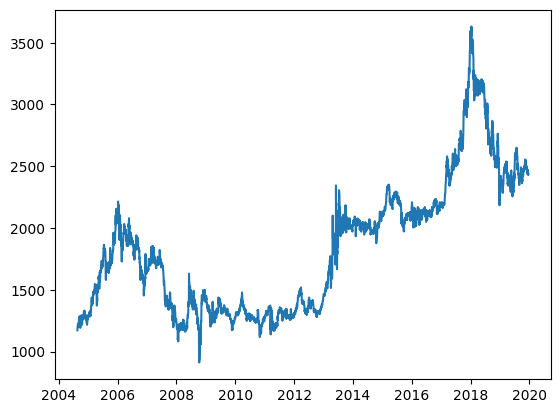

In [5]:
plt.plot(google["Open"])
plt.show()

In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_google = scaler.fit_transform(google[["Open"]])
scaled_nke = scaler.fit_transform(nke[["Open"]])

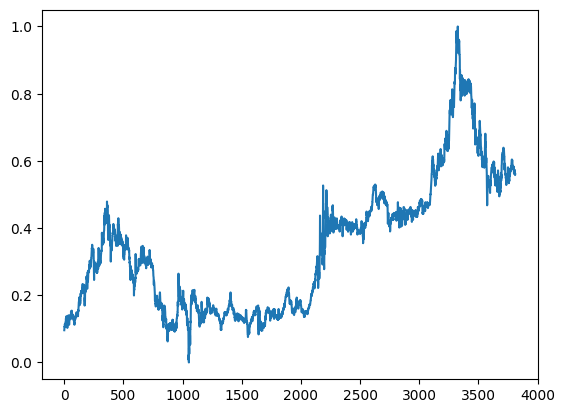

In [7]:
plt.plot(scaled_google)
plt.show()

In [5]:
scaled_google = scaled_nke

In [6]:
look_back = 60  # 過去60日から次の日を予測

# データ準備
X, y = [], []
for i in range(look_back, len(scaled_google)):
    X.append(scaled_google[i-look_back:i, 0])  # 直近60日のデータ
    y.append(scaled_google[i, 0])              # 翌日

X, y = np.array(X), np.array(y)

# 学習データ・テストデータに分割
train_range = int(len(X) * 0.8)
X_train, X_test = X[:train_range], X[train_range-look_back:]
y_train, y_test = y[:train_range], y[train_range-look_back:]

# LSTM用に3次元化
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test  = np.reshape(X_test,  (X_test.shape[0],  X_test.shape[1],  1))

print(X_train.shape)  # 例: (2000, 60, 1)

(3131, 60, 1)


### 2. 簡易的なLSTMモデルを構築

In [9]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=1))

model.compile(optimizer="Adam", loss="mean_squared_error")
model.fit(X_train, y_train, epochs=50, batch_size=32, callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=5)])

Epoch 1/50


c:\Users\togen\FINAL_PAPER\research_using_uv\.venv310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.0042
Epoch 2/50
 3/94 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0012

c:\Users\togen\FINAL_PAPER\research_using_uv\.venv310\lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 9.2761e-04
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 8.3422e-04
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 8.0150e-04
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 7.4837e-04
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 6.6270e-04
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 6.3493e-04
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 5.9302e-04
Epoch 9/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 5.8491e-04
Epoch 10/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 5.6222e-04
Epoch 11/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 4.9784e-04
Epoch 12/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 4.7013e-04
Epoch 13/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 4.6921e-04
Epoch 14/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 4.2898e-04
Epoch 15/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 4.9817e-04
Epoch 16/50
94/94 ━━━━━━━

In [7]:
model = pickle.load(open(Path("../model/simple_LSTM/GOOGL/simple_LSTM_30.pkl"), "rb"))

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


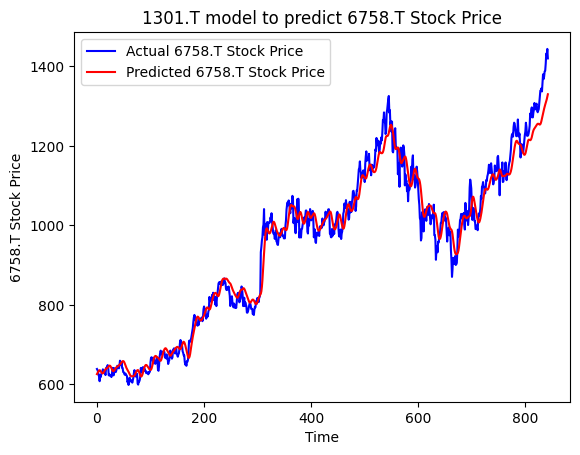

In [10]:
Observations = y_test
Predictions = model.predict(X_test)
Observations = scaler.inverse_transform(Observations.reshape(-1, 1))
Predictions = scaler.inverse_transform(Predictions)

plt.plot(Observations, color="blue", label="Actual 6758.T Stock Price")
plt.plot(Predictions, color="red", label="Predicted 6758.T Stock Price")
plt.title("1301.T model to predict 6758.T Stock Price")
plt.xlabel("Time")
plt.ylabel("6758.T Stock Price")
plt.legend()
plt.show()

In [28]:
rmse = np.sqrt(np.mean((Predictions - Observations) ** 2))
print(f"RMSE: {rmse}")

RMSE: 168.34124639595154


In [9]:
mape = np.mean(np.abs((Observations - Predictions) / Observations)) * 100
print(f"MAPE: {mape}%")

MAPE: 2.7102709010419286%


In [14]:
range_num = 30

In [15]:
Observations_df = pd.DataFrame(Observations, columns=["Actual"]).reset_index(drop=True)
Predictions_df = pd.DataFrame(Predictions, columns=["Predicted"]).reset_index(drop=True)
shift_series = pd.concat(
    [Predictions_df.diff().shift(-1).shift(-i) for i in range(-range_num, range_num)], axis=1
)


In [16]:
shift_series = pd.concat(
    [Predictions_df.diff().shift(-1), shift_series, Observations_df.diff().shift(-1)], axis=1
)

In [17]:
shift_series.columns = ['Predicted'] + [f'Predicted_lag_{i}' for i in range(-range_num, range_num)] + ['Actual']

In [18]:
shift_series

,Predicted,Predicted_lag_-30,Predicted_lag_-29,Predicted_lag_-28,Predicted_lag_-27,Predicted_lag_-26,Predicted_lag_-25,Predicted_lag_-24,Predicted_lag_-23,Predicted_lag_-22,...,Predicted_lag_21,Predicted_lag_22,Predicted_lag_23,Predicted_lag_24,Predicted_lag_25,Predicted_lag_26,Predicted_lag_27,Predicted_lag_28,Predicted_lag_29,Actual
0,21.473145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.161865,-6.143311,-2.911865,5.087891,2.495117,-29.223877,-36.807861,-5.461182,-0.191650,-1.607790
1,6.512695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-6.143311,-2.911865,5.087891,2.495117,-29.223877,-36.807861,-5.461182,-0.191650,-3.006348,7.235171
2,3.889160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-2.911865,5.087891,2.495117,-29.223877,-36.807861,-5.461182,-0.191650,-3.006348,-0.288086,2.411011
3,2.980957,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.087891,2.495117,-29.223877,-36.807861,-5.461182,-0.191650,-3.006348,-0.288086,-6.734131,0.804501
4,2.526611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.495117,-29.223877,-36.807861,-5.461182,-0.191650,-3.006348,-0.288086,-6.734131,-7.695068,12.862124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806,0.270508,-5.655518,4.291260,-9.819580,18.527832,11.485596,6.248291,12.267334,-20.701172,9.911621,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.008665
807,11.911377,4.291260,-9.819580,18.527832,11.485596,6.248291,12.267334,-20.701172,9.911621,15.343262,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-24.713124
808,-10.437256,-9.819580,18.527832,11.485596,6.248291,12.267334,-20.701172,9.911621,15.343262,-15.931152,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-17.043383
809,-12.463379,18.527832,11.485596,6.248291,12.267334,-20.701172,9.911621,15.343262,-15.931152,-9.427246,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.669591


In [19]:
import scipy.stats as stats
import seaborn as sns
standardized_data = (stats.zscore(shift_series.dropna()))
lagged_df = pd.DataFrame(standardized_data, columns=['Predicted'] + [f'Predicted_lag_{i}' for i in range(-range_num, range_num)] + ['Actual'])
corr = lagged_df.corr()['Actual']

In [20]:
# sns.pairplot(lagged_df)

In [21]:
corr

Predicted           -0.055191
Predicted_lag_-30   -0.008880
Predicted_lag_-29   -0.009167
Predicted_lag_-28   -0.089809
Predicted_lag_-27    0.030899
                       ...   
Predicted_lag_26     0.021053
Predicted_lag_27    -0.026816
Predicted_lag_28    -0.068074
Predicted_lag_29     0.036408
Actual               1.000000
Name: Actual, Length: 62, dtype: float64

Text(0, 0.5, 'cross-correlation')

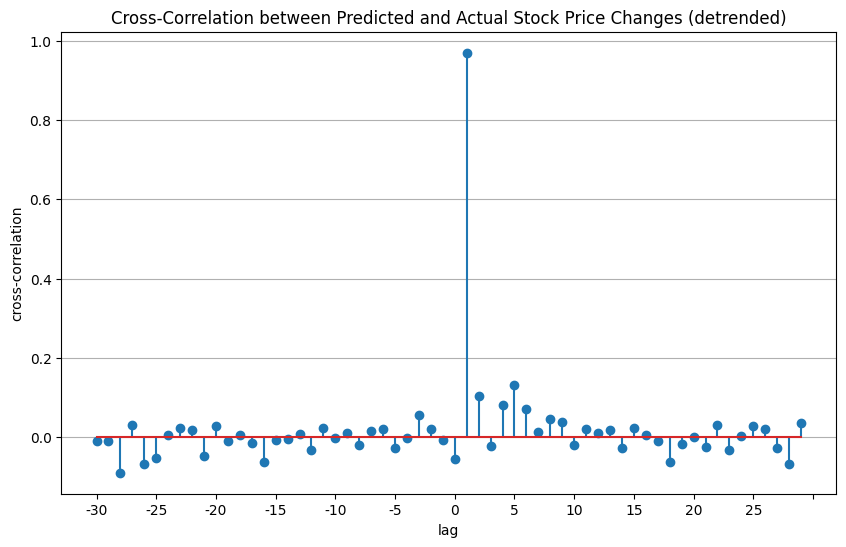

In [22]:
plt.figure(figsize=(10, 6))
plt.stem([f'{i}' for i in range(-range_num, range_num)], corr[1:-1])
plt.xlabel("lag")
plt.title("Cross-Correlation between Predicted and Actual Stock Price Changes (detrended)")
plt.grid(axis='y')
plt.xticks(range(0, len(corr), 5))
plt.ylabel("cross-correlation")

In [79]:
actual_lagged_series = pd.concat(
    [Observations_df.diff().shift(-1).shift(-i) for i in range(1, 10)] + [Observations_df.diff().shift(-1)], axis=1
)

In [62]:
actual_lagged_series.columns = [f'Actual_lag_{i}' for i in range(1, 10)] + ['Actual']

In [66]:
actual_lagged_series

,Actual_lag_1,Actual_lag_2,Actual_lag_3,Actual_lag_4,Actual_lag_5,Actual_lag_6,Actual_lag_7,Actual_lag_8,Actual_lag_9,Actual
0,0.128055,-0.068011,0.077198,0.535473,0.314919,-0.325951,-0.489525,0.137854,0.192992,0.552010
1,-0.068011,0.077198,0.535473,0.314919,-0.325951,-0.489525,0.137854,0.192992,-0.222397,0.128055
2,0.077198,0.535473,0.314919,-0.325951,-0.489525,0.137854,0.192992,-0.222397,-0.064334,-0.068011
3,0.535473,0.314919,-0.325951,-0.489525,0.137854,0.192992,-0.222397,-0.064334,0.150103,0.077198
4,0.314919,-0.325951,-0.489525,0.137854,0.192992,-0.222397,-0.064334,0.150103,0.061275,0.535473
...,...,...,...,...,...,...,...,...,...,...
816,0.435028,0.453971,-0.331444,NaN,NaN,NaN,NaN,NaN,NaN,0.287333
817,0.453971,-0.331444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.435028
818,-0.331444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.453971
819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.331444


In [67]:
auto_corr = pd.DataFrame(actual_lagged_series, columns=[f'Actual_lag_{i}' for i in range(1, 10)] + ['Actual']).corr()['Actual']

In [68]:
auto_corr

Actual_lag_1   -0.085513
Actual_lag_2   -0.005729
Actual_lag_3    0.052313
Actual_lag_4   -0.099405
Actual_lag_5   -0.029199
Actual_lag_6   -0.031109
Actual_lag_7    0.031611
Actual_lag_8   -0.036826
Actual_lag_9   -0.095439
Actual          1.000000
Name: Actual, dtype: float64

Text(0, 0.5, 'auto-correlation')

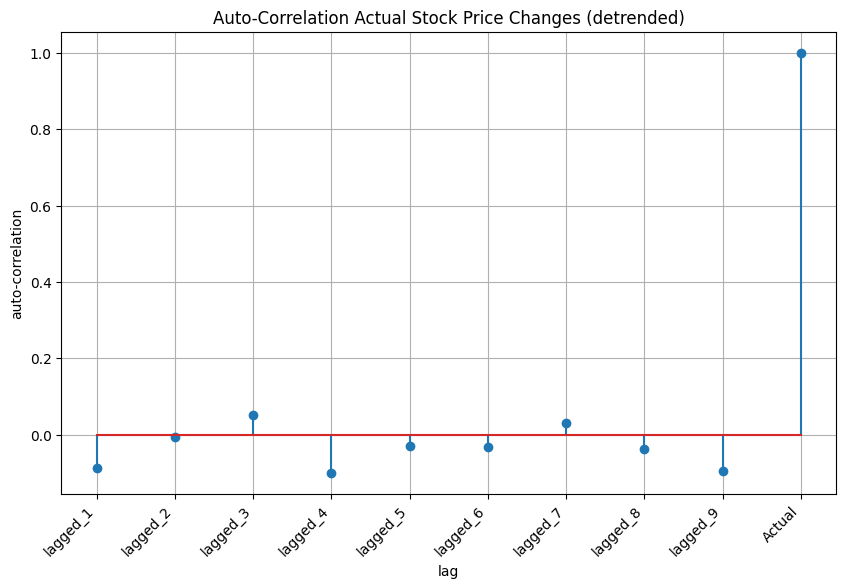

In [70]:
plt.figure(figsize=(10, 6))
plt.stem([f'lagged_{i}' for i in range(1, 10)] + ['Actual'], auto_corr)
plt.xlabel("lag")
plt.title("Auto-Correlation Actual Stock Price Changes (detrended)")
plt.grid(True)
plt.xticks(rotation=45, ha='right')
# plt.ylim(0.975, 1.0)
plt.ylabel("auto-correlation")

In [ ]:
toyota_predictions = model.predict(X_test)

### 3. 予測結果

In [ ]:
models = [model_path for model_path in Path('../model/simple_LSTM/GOOGL/').rglob('.') if model_path.suffix == '.pkl'] # model\simple_LSTM\GOOGL\simple_LSTM_10.pkl
models.sort()
print(models)

for i, model_path in enumerate(models):
    model = None
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
        epochs = (i + 1) * 10

    title = 'Stock Price Prediction (epochs={})'.format(epochs)
    predicted = model.predict(X_test)
    # y_test = y_test.reshape(y_test.shape[0], y_test.shape[1])
    y_test_originnal_scaled = scaler.inverse_transform(y_test.reshape(y_test.shape[0], 1))
    predicted_originnal_scaled = scaler.inverse_transform(predicted)
    # plt.plot(google["Open"], color='green', label='Real Stock Price')
    lower_ylim = min(y_test_originnal_scaled[~np.isnan(y_test_originnal_scaled)][400:500].min(), predicted_originnal_scaled[~np.isnan(predicted_originnal_scaled)][400:500].min())
    upper_ylim = max(y_test_originnal_scaled[~np.isnan(y_test_originnal_scaled)][400:500].max(), predicted_originnal_scaled[~np.isnan(predicted_originnal_scaled)][400:500].max())
    plt.plot(y_test_originnal_scaled, color='blue', label='Real Stock Price')
    plt.plot(predicted_originnal_scaled, color='red', label='Predicted Stock Price')
    plt.title(title)
    plt.xlim(400, 500)
    plt.ylim(lower_ylim, upper_ylim)
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.savefig('../images/simple_LSTM/GOOGL/partial_zoom/' + title + '.png') # images\simple_LSTM\GOOGL
    plt.legend()
    plt.show()

In [ ]:
# with open(f"../model/simple_LSTM_{epochs}.pkl", "wb") as f:
#     pickle.dump(model, f)